In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("../data/processed/traffic_features.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

df.shape

(17267, 23)

In [3]:
# Baseline: predict that the next value equals the most recent value
ns_baseline_prediction = df["ns_lag_1"]
ew_baseline_prediction = df["ew_lag_1"]

ns_mae_baseline = mean_absolute_error(df["ns_target"], ns_baseline_prediction)
ew_mae_baseline = mean_absolute_error(df["ew_target"], ew_baseline_prediction)

ns_rmse_baseline = np.sqrt(mean_squared_error(df["ns_target"], ns_baseline_prediction))
ew_rmse_baseline = np.sqrt(mean_squared_error(df["ew_target"], ew_baseline_prediction))

print("North-South baseline MAE:", ns_mae_baseline)
print("East-West baseline MAE:", ew_mae_baseline)
print("North-South baseline RMSE:", ns_rmse_baseline)
print("East-West baseline RMSE:", ew_rmse_baseline)

North-South baseline MAE: 4.585104534661493
East-West baseline MAE: 4.509468929171251
North-South baseline RMSE: 5.7536087315730855
East-West baseline RMSE: 5.644129666057002


In [4]:
# Define which columns the model is allowed to use as input
feature_columns = [
    "hour", "minute", "day_of_week", "is_weekend",
    "ns_lag_1", "ns_lag_2", "ns_lag_3", "ns_lag_6", "ns_lag_12",
    "ew_lag_1", "ew_lag_2", "ew_lag_3", "ew_lag_6", "ew_lag_12",
    "ns_rolling_mean_3", "ew_rolling_mean_3",
    "ns_rolling_mean_6", "ew_rolling_mean_6"
]

X = df[feature_columns]
y_ns = df["ns_target"]
y_ew = df["ew_target"]

# Split chronologically: first 80% for training, last 20% for testing
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_ns_train = y_ns.iloc[:split_index]
y_ns_test = y_ns.iloc[split_index:]

y_ew_train = y_ew.iloc[:split_index]
y_ew_test = y_ew.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 13813
Testing rows: 3454


In [5]:
from sklearn.ensemble import RandomForestRegressor

ns_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

ew_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

ns_model.fit(X_train, y_ns_train)
ew_model.fit(X_train, y_ew_train)

print("Both models trained.")

Both models trained.


In [6]:
ns_predictions = ns_model.predict(X_test)
ew_predictions = ew_model.predict(X_test)

def evaluate_model(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    print(f"\n{model_name}")
    print(f"MAE: {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2 Score: {r2:.3f}")

    return mae, rmse, r2

ns_results = evaluate_model(y_ns_test, ns_predictions, "North-South Random Forest")
ew_results = evaluate_model(y_ew_test, ew_predictions, "East-West Random Forest")


North-South Random Forest
MAE: 3.320
RMSE: 4.141
R2 Score: 0.873

East-West Random Forest
MAE: 3.404
RMSE: 4.210
R2 Score: 0.887


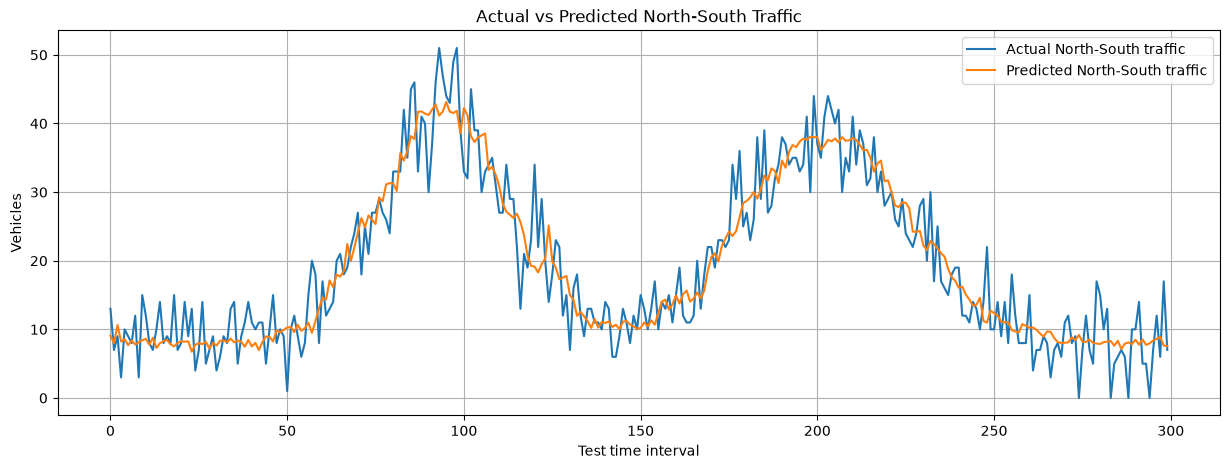

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(y_ns_test.iloc[:300].values, label="Actual North-South traffic")
plt.plot(ns_predictions[:300], label="Predicted North-South traffic")
plt.xlabel("Test time interval")
plt.ylabel("Vehicles")
plt.title("Actual vs Predicted North-South Traffic")
plt.legend()
plt.grid(True)
plt.savefig("../results/ns_actual_vs_predicted.png")
plt.show()

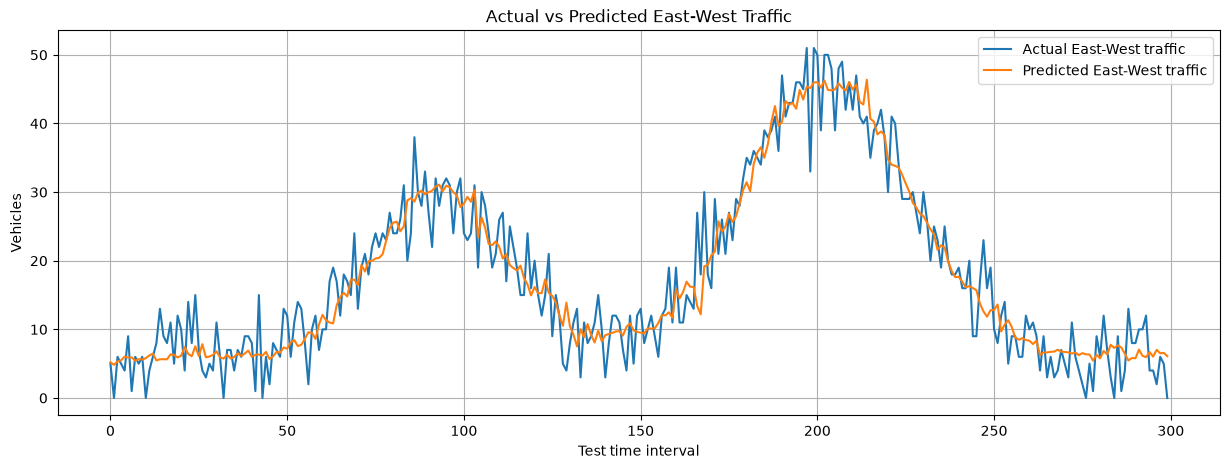

In [8]:
plt.figure(figsize=(15, 5))
plt.plot(y_ew_test.iloc[:300].values, label="Actual East-West traffic")
plt.plot(ew_predictions[:300], label="Predicted East-West traffic")
plt.xlabel("Test time interval")
plt.ylabel("Vehicles")
plt.title("Actual vs Predicted East-West Traffic")
plt.legend()
plt.grid(True)
plt.savefig("../results/ew_actual_vs_predicted.png")
plt.show()

In [9]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(ns_model, "../models/ns_traffic_model.pkl")
joblib.dump(ew_model, "../models/ew_traffic_model.pkl")
joblib.dump(feature_columns, "../models/feature_columns.pkl")

print("Models saved successfully.")


Models saved successfully.
